# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from typing import Union, List, Iterable
from joblib import Parallel, delayed, cpu_count
from datetime import datetime 

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from statsmodels.regression.linear_model import OLS

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [5]:
from core.variables import *
from core.dgp import SingleSegment
import core.multiple_treatments_single_segment as mtss

# DGP

In [6]:
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}

dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(sample_size=1000, seed=0)

# Demand Model

In [7]:
emp_te_arr = mtss.difference_in_mean(
    treatments=treatment_arr, outcomes=outcome_arr,
    treatment_vals=dgp_params['treatment_space']
)

# display
for idx, te_est in enumerate(emp_te_arr):
    if idx == 0:
        continue 
    
    print(f'Treatment value: {dgp.treatment_space[idx]}, Estiamted TE: {te_est:.4f}, True TE: {dgp.lift_arr[idx]:.4f}')

Treatment value: 1, Estiamted TE: 0.6710, True TE: 0.6000
Treatment value: 2, Estiamted TE: 1.0295, True TE: 1.2000
Treatment value: 3, Estiamted TE: 1.9261, True TE: 1.8000
Treatment value: 4, Estiamted TE: 2.3537, True TE: 2.4000


# Optimization

In [8]:
plugin_decision, plugin_val_est = mtss.optimize(
    customer_tes=emp_te_arr, 
    treatment_space=dgp_params['treatment_space'],
    price=1, cost=0.5
)

true_plugin_val = mtss.obj_func(
    customer_tes=dgp.lift_arr, 
    targ_decision=plugin_decision,
    price=1, cost=0.5
)

print(f'Estimated targing value: {plugin_val_est:.4f}, True targeting value: {true_plugin_val:.4f}')

Estimated targing value: 0.4261, True targeting value: 0.3000


# Winner's Curse

In [32]:
operations_params = {'price': 1, 'cost': 0.5}
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}
data_params = {'sample_size': 100}
experiment_params = {'n_experiments': 5000, 'conditional_on_treated': True, 'stats': 'mean'}

estimators_dict = {}

result_records = mtss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, verbose=True
)

emp_wc_arr = np.array([record['plugin_wc'] for record in result_records])
emp_wc_pct_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])
emp_roi_wc_arr = 100 * np.array([record['plugin_roi_wc'] for record in result_records])

avg_wc = np.mean(emp_wc_arr)
avg_wc_pct = np.mean(emp_wc_pct_arr)
avg_roi_wc = np.mean(emp_roi_wc_arr)
se_wc = np.std(emp_wc_arr) / np.sqrt(data_params['sample_size'])
se_wc_pct = np.std(emp_wc_pct_arr) / np.sqrt(data_params['sample_size'])
se_roi_wc = np.std(emp_roi_wc_arr) / np.sqrt(data_params['sample_size'])

print(f'Average Empirical Winner\'s Curse: {avg_wc:.2f} ({se_wc:.2f})')
print(f'Average Empirical Winner\'s Curse Percentage: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')
print(f'Average Empirical Winner\'s Curse ROI: {avg_roi_wc:.2f}% ({se_roi_wc:.2f}%)')


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Average Empirical Winner's Curse: 0.55 (0.05)
Average Empirical Winner's Curse Percentage: 254.91% (29.80%)
Average Empirical Winner's Curse ROI: 50.98% (5.96%)


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 3382 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.0s finished


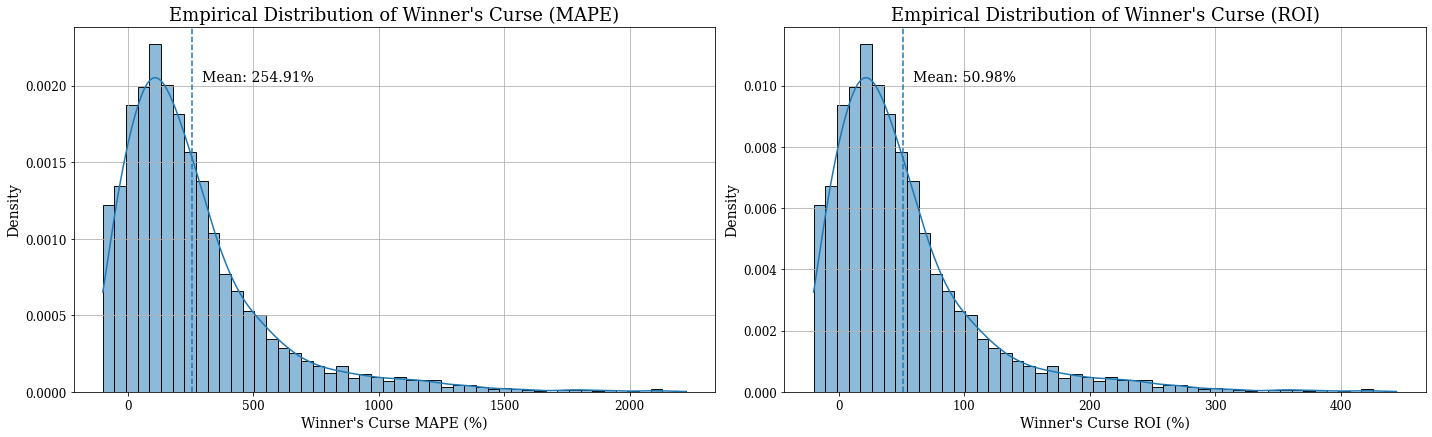

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

sns.histplot(emp_wc_pct_arr, bins=50, kde=True, stat='density', ax=axes[0], color='C0')
axes[0].axvline(emp_wc_pct_arr.mean(), color='C0', linestyle='--')
axes[0].annotate(
    f"Mean: {emp_wc_pct_arr.mean():.2f}%", 
    xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
axes[0].set_title("Empirical Distribution of Winner's Curse (MAPE)", fontsize=title_size)

axes[0].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[0].set_xlabel("Winner's Curse MAPE (%)", fontsize=axis_label_size)
axes[0].set_ylabel('Density', fontsize=axis_label_size)
axes[0].grid()

sns.histplot(emp_roi_wc_arr, bins=50, kde=True, stat='density', ax=axes[1], color='C0')
axes[1].axvline(emp_roi_wc_arr.mean(), color='C0', linestyle='--')
axes[1].annotate(
    f"Mean: {emp_roi_wc_arr.mean():.2f}%", 
    xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
axes[1].set_title("Empirical Distribution of Winner's Curse (ROI)", fontsize=title_size)
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[1].set_xlabel("Winner's Curse ROI (%)", fontsize=axis_label_size)
axes[1].set_ylabel('Density', fontsize=axis_label_size)
axes[1].grid()

plt.tight_layout()
plt.savefig('figures/case2-winners-curse-dstn.png')
plt.show()

## Standard Bootstrap

# Estimating winner's curse

In [11]:
dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(**data_params, seed=1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


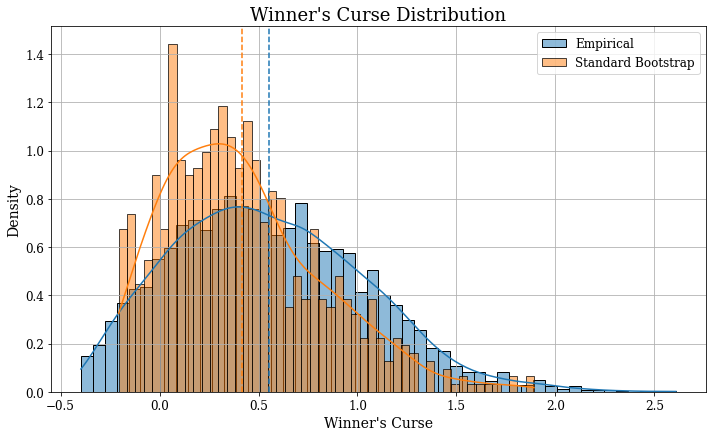

In [12]:
boot_wc_dstn_arr = mtss.get_wc_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    treatment_space=dgp_params['treatment_space'],
    price=1, cost=0.5,
    n_bootstraps=1000, n_jobs=-1, verbose=True, conditional_on_treated=True
)

fig, ax = plt.subplots(figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=ax)
ax.axvline(np.nanmean(emp_wc_arr), color='C0', linestyle='--')

# bootstrap winner's curse
sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=ax)
ax.axvline(np.nanmean(boot_wc_dstn_arr), color='C1', linestyle='--')

ax.set_title('Winner\'s Curse Distribution', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()
plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


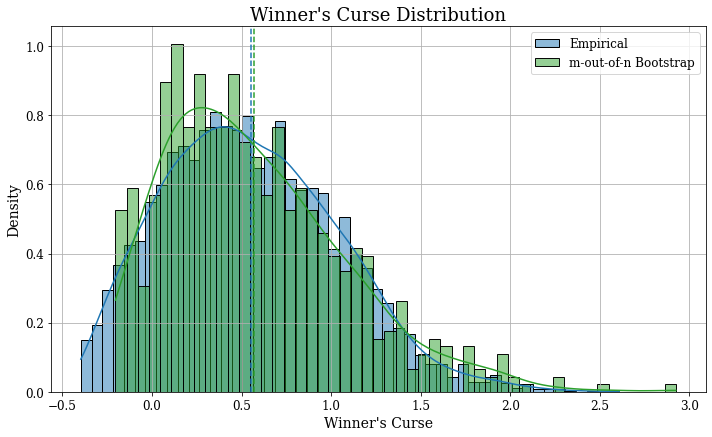

In [13]:
mn_boot_wc_dstn_arr = mtss.get_wc_m_out_of_n_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    treatment_space=dgp_params['treatment_space'],
    price=1, cost=0.5,
    n_bootstraps=1000, power=0.9, 
    n_jobs=-1, verbose=True, conditional_on_treated=True 
)

fig, ax = plt.subplots(figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=ax)
ax.axvline(np.nanmean(emp_wc_arr), color='C0', linestyle='--')

# bootstrap winner's curse
sns.histplot(mn_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C2', label='m-out-of-n Bootstrap', ax=ax)
ax.axvline(np.nanmean(mn_boot_wc_dstn_arr), color='C2', linestyle='--')

ax.set_title('Winner\'s Curse Distribution', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()
plt.tight_layout()
plt.show()

## Numerical Bootstrap

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


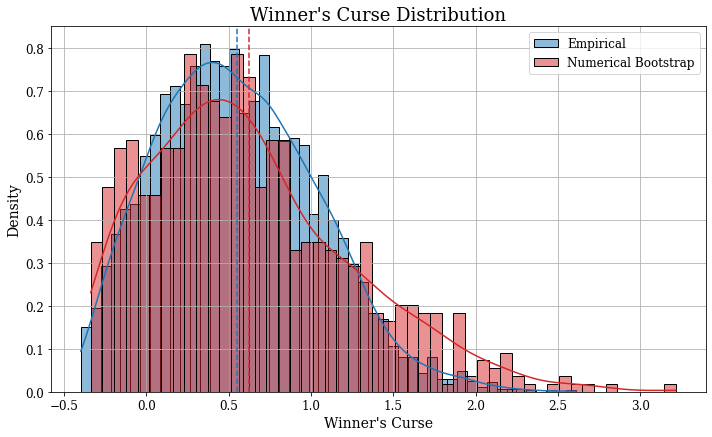

In [14]:
num_boot_wc_dstn_arr = mtss.get_wc_num_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    treatment_space=dgp_params['treatment_space'],
    price=1, cost=0.5,
    n_bootstraps=1000, power=-0.4, 
    n_jobs=-1, verbose=True, conditional_on_treated=True
)

fig, ax = plt.subplots(figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=ax)
ax.axvline(np.nanmean(emp_wc_arr), color='C0', linestyle='--')

# bootstrap winner's curse
sns.histplot(num_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C3', label='Numerical Bootstrap', ax=ax)
ax.axvline(np.nanmean(num_boot_wc_dstn_arr), color='C3', linestyle='--')

ax.set_title('Winner\'s Curse Distribution', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()
plt.tight_layout()
plt.show()

# Bias Correction

In [28]:
operations_params = {'price': 1, 'cost': 0.5}
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}
data_params = {'sample_size': 100}
experiment_params = {'n_experiments': 10000, 'conditional_on_treated': True, 'stats': 'mean'}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}
    }, 
    'mn_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.9, 'n_jobs': 1}
    }, 
    'num_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.4, 'n_jobs': 1}
    }
}

In [29]:
result_records = mtss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   20.5s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:   38.4s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 6030 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 7180 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 8430 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 9780 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 10000 out of 1000

In [30]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc_pct'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})
roi_wc_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_roi_wc'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = np.mean(wc_pct_df[estimator])
    se_wc_pct = np.std(wc_pct_df[estimator]) / np.sqrt(data_params['sample_size'])
    avg_roi_wc = np.mean(roi_wc_df[estimator])
    se_roi_wc = np.std(roi_wc_df[estimator]) / np.sqrt(data_params['sample_size'])
    print(f'\nWinner\'s Curse MAPE of {estimator}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')
    print(f'Overestimated ROI of {estimator}: {avg_roi_wc:.2f}% ({se_roi_wc:.2f}%)')



Winner's Curse MAPE of plugin: 255.03% (30.38%)
Overestimated ROI of plugin: 51.01% (6.08%)

Winner's Curse MAPE of standard_bootstrap: 102.88% (28.18%)
Overestimated ROI of standard_bootstrap: 20.58% (5.64%)

Winner's Curse MAPE of mn_bootstrap: 40.08% (27.33%)
Overestimated ROI of mn_bootstrap: 8.02% (5.47%)

Winner's Curse MAPE of num_bootstrap: 14.08% (28.73%)
Overestimated ROI of num_bootstrap: 2.82% (5.75%)


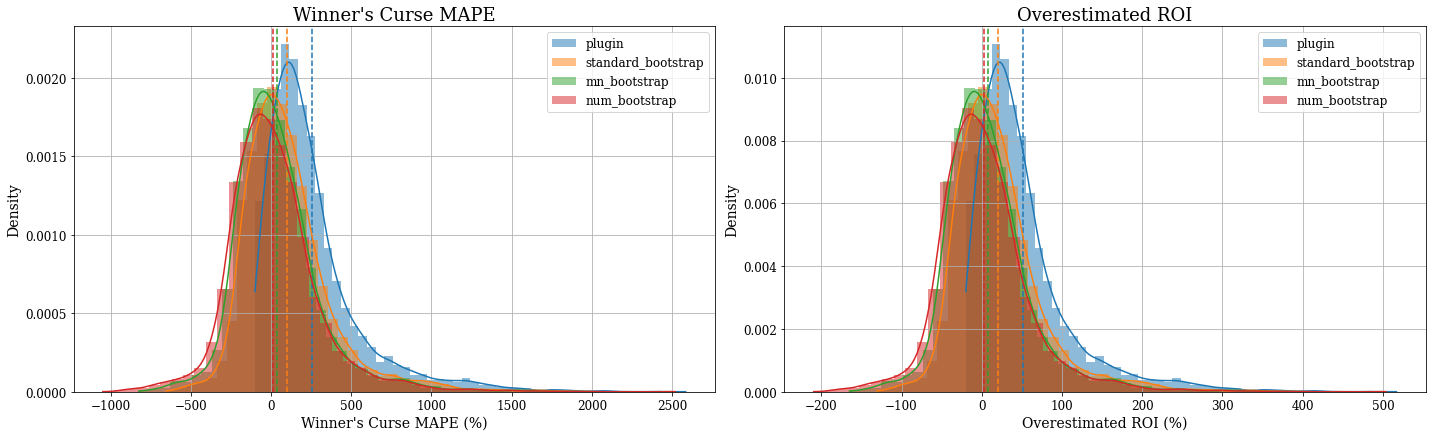

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

# winner's curse MAPE
for idx, estimator in enumerate(['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(wc_pct_df, x=estimator, bins=50, kde=True, stat='density', ax=axes[0], color=f'C{idx}', edgecolor=None, label=estimator)
    axes[0].axvline(wc_pct_df[estimator].mean(), color=f'C{idx}', linestyle='--')

axes[0].set_title('Winner\'s Curse MAPE', fontsize=title_size)
axes[0].set_xlabel('Winner\'s Curse MAPE (%)', fontsize=axis_label_size)

# overestimated ROI
for idx, estimator in enumerate(['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(roi_wc_df, x=estimator, bins=50, kde=True, stat='density', ax=axes[1], color=f'C{idx}', edgecolor=None, label=estimator)
    axes[1].axvline(roi_wc_df[estimator].mean(), color=f'C{idx}', linestyle='--')

axes[1].set_title('Overestimated ROI', fontsize=title_size)
axes[1].set_xlabel('Overestimated ROI (%)', fontsize=axis_label_size)

for ax in axes:
    ax.tick_params(labelsize=tick_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.set_ylabel('Density', fontsize=axis_label_size)
    ax.grid()

plt.tight_layout()
# plt.savefig('figures/case2-bias-correction.png')
plt.show()

# Sensitivity Analysis

## Sample Size

In [24]:
operations_params = {'price': 1, 'cost': 0.5}
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}
data_params = {'sample_size': np.nan}
experiment_params = {'n_experiments': 10000}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}
    }, 
    'mn_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.97, 'n_jobs': 1}
    }, 
    'num_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.47, 'n_jobs': 1}
    }
}

In [ ]:
sample_size_result_dict = mtss.sample_size_test(
    sample_sizes=[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000],
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True, 
    save_path='results/case2_sample_size_test.pkl'
)

In [16]:
with open('results/case2_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

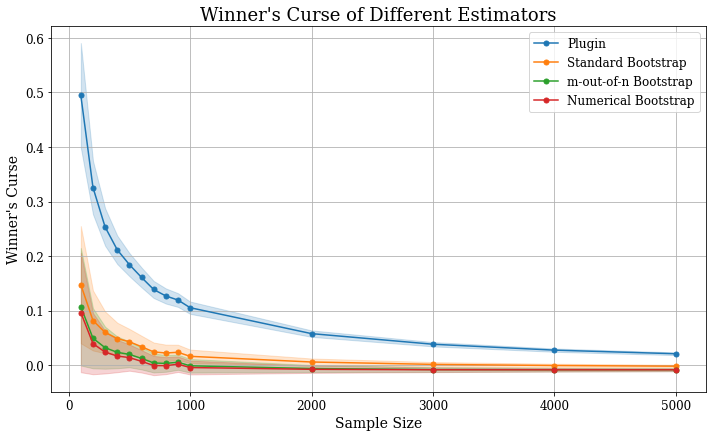

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_wc_mean'], 'o-', markersize=5, label='Plugin', color='C0')
ax.fill_between(
    result_df.index, 
    result_df['plugin_wc_mean'] - 1.96 * result_df['plugin_wc_se'],
    result_df['plugin_wc_mean'] + 1.96 * result_df['plugin_wc_se'],
    color='C0', alpha=0.2
)

# standard bootstrap 
ax.plot(result_df.index, result_df['standard_bootstrap_wc_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
ax.fill_between(
    result_df.index,
    result_df['standard_bootstrap_wc_mean'] - 1.96 * result_df['standard_bootstrap_wc_se'],
    result_df['standard_bootstrap_wc_mean'] + 1.96 * result_df['standard_bootstrap_wc_se'],
    color='C1', alpha=0.2
)

# m out of n bootstrap
ax.plot(result_df.index, result_df['mn_bootstrap_wc_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    result_df.index, 
    result_df['mn_bootstrap_wc_mean'] - 1.96 * result_df['mn_bootstrap_wc_se'], 
    result_df['mn_bootstrap_wc_mean'] + 1.96 * result_df['mn_bootstrap_wc_se'], 
    color='C2', alpha=0.2
)

# numerical bootstrap
ax.plot(result_df.index, result_df['num_bootstrap_wc_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
ax.fill_between(
    result_df.index, 
    result_df['num_bootstrap_wc_mean'] - 1.96 * result_df['num_bootstrap_wc_se'], 
    result_df['num_bootstrap_wc_mean'] + 1.96 * result_df['num_bootstrap_wc_se'], 
    color='C3', alpha=0.2
)


ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/case1-sample-size-test.png')
plt.show()

## Large Sample Size

In [38]:
data_params = {'sample_size': 1000000}

extreme_sample_size_result_records = mtss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True, 
    save_path='results/case2_large_sample_size.pkl'
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [6]:
with open('results/case2_large_sample_size.pkl', 'rb') as f:
    result_records = pickle.load(f)
result_df = pd.DataFrame.from_records(result_records)

In [7]:
for estimator in ['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']:
    avg_wc = np.nanmean(result_df[f'{estimator}_wc'])
    se_wc = np.nanstd(result_df[f'{estimator}_wc']) / np.sqrt(100000)

    avg_wc_pct = np.nanmean(result_df[f'{estimator}_wc_pct'])
    se_wc_pct = np.nanstd(result_df[f'{estimator}_wc_pct']) / np.sqrt(100000)

    print(f'{estimator}: winner\'s curse: {avg_wc:.4f} ({se_wc:.4f}), winner\'s curse (%): {avg_wc_pct:.4f} ({se_wc_pct:.4f})')

plugin: winner's curse: 0.0010 (0.0000), winner's curse (%): 0.0024 (0.0001)
standard_bootstrap: winner's curse: 0.0010 (0.0000), winner's curse (%): 0.0024 (0.0001)
mn_bootstrap: winner's curse: 0.0009 (0.0000), winner's curse (%): 0.0023 (0.0001)
num_bootstrap: winner's curse: 0.0010 (0.0000), winner's curse (%): 0.0026 (0.0000)


## Noise Level 

In [7]:
operations_params = {'price': 1, 'cost': 0.5}
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}
data_params = {'sample_size': 1000}
experiment_params = {'n_experiments': 10000}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}
    }, 
    'mn_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.97, 'n_jobs': 1}
    }, 
    'num_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.47, 'n_jobs': 1}
    }
}

In [8]:
noise_level_result_dict = mtss.noise_level_test(
    noise_stds=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True, 
    save_path='results/case2_noise_level_test.pkl'
)


Running nnoise_level 1 (1/10)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   20.8s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   34.9s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:   55.9s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 6030 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done 7180 tasks      | elapsed:  6.5min
[Parallel(n_jobs=-1)]: Done 8430 tasks      | elapsed:  7.3min
[Parallel(n_jobs=-1)]: Done 9780 tasks      | elapsed:  8.3min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  8.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBacken

Finished noise_level 1 in 0:08:24.768467

Running nnoise_level 2 (2/10)


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   23.7s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   47.4s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 6030 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 7180 tasks      | elapsed:  7.3min
[Parallel(n_jobs=-1)]: Done 8430 tasks      | elapsed:  8.5min
[Parallel(n_jobs=-1)]: Done 9780 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed: 10.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBacken

...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   17.9s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   31.9s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:   49.9s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 6030 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-1)]: Done 7180 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 8430 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done 9780 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  6.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBacken

Finished noise_level 9 in 0:06:44.190775

Running nnoise_level 10 (10/10)


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   17.3s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   31.7s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:   49.4s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 6030 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 7180 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 8430 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 9780 tasks      | elapsed:  6.5min


Finished noise_level 10 in 0:06:40.858297


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  6.7min finished


In [10]:
with open('results/case2_noise_level_test.pkl', 'rb') as file:
    result_dict = pickle.load(file)

result_df = pd.DataFrame.from_dict(result_dict).T

KeyError: 'plugin_mean'

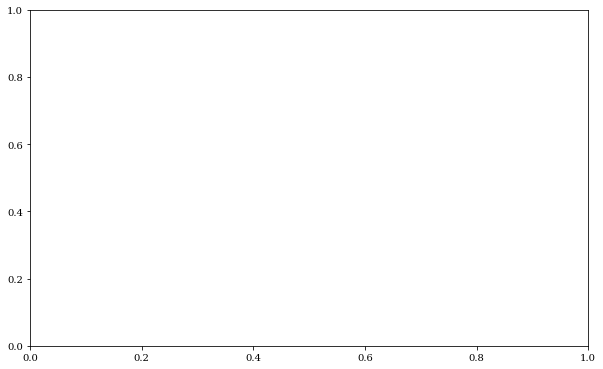

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')
ax.fill_between(
    result_df.index, 
    result_df['plugin_mean'] - 1.96 * result_df['plugin_se'], 
    result_df['plugin_mean'] + 1.96 * result_df['plugin_se'], 
    color='C0', alpha=0.3
)
# ax.errorbar(
#     x=result_df.index, y=result_df['plugin_mean'], yerr= 1.96 * result_df['plugin_se'], 
#     fmt='o', capsize=5, label='Plugin', color='C0'
# )

# standard bootstrap 
ax.plot(result_df.index, result_df['stand_bootstrap_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
ax.fill_between(
    result_df.index, 
    result_df['stand_bootstrap_mean'] - 1.96 * result_df['stand_bootstrap_se'], 
    result_df['stand_bootstrap_mean'] + 1.96 * result_df['stand_bootstrap_se'], 
    color='C1', alpha=0.3
)

# m out of n bootstrap
ax.plot(result_df.index, result_df['mn_bootstrap_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    result_df.index, 
    result_df['mn_bootstrap_mean'] - 1.96 * result_df['mn_bootstrap_se'], 
    result_df['mn_bootstrap_mean'] + 1.96 * result_df['mn_bootstrap_se'], 
    color='C2', alpha=0.3
)

# numerical bootstrap
ax.plot(result_df.index, result_df['num_bootstrap_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
ax.fill_between(
    result_df.index, 
    result_df['num_bootstrap_mean'] - 1.96 * result_df['num_bootstrap_se'], 
    result_df['num_bootstrap_mean'] + 1.96 * result_df['num_bootstrap_se'], 
    color='C3', alpha=0.3
)

ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Noise Level', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
# plt.savefig('figures/case1-sample-size-test.png')
plt.show()